# 🥤 CodeX Beverage Market Analysis
## Codebasics Resume Project Challenge — Case Study 6

| | |
|---|---|
| **Analyst** | Dhaval Dupare |
| **Domain** | Food & Beverage — Energy Drinks |
| **Tools** | Python · Pandas · Matplotlib · NumPy |
| **Dataset** | 10,000 survey respondents across 10 Indian cities |
| **Objective** | Convert survey data into actionable marketing insights for CodeX |

---

### 🎯 Business Context
CodeX is a German energy drink brand that recently launched in 10 Indian cities.  
Their marketing team needs data-driven answers to grow brand awareness, increase market share, and guide product development.

### 📋 Analysis Roadmap
1. Demographic Insights  
2. Brand Awareness by City  
3. Competition Analysis  
4. Product Improvements Desired  
5. Marketing Channel Effectiveness  
6. Consumer Preferences — Ingredients & Packaging  
7. Market Leaders  
8. Brand Perception  
9. Purchase Behaviour  
10. Business Recommendations


---
## Step 1 — Environment Setup & Data Loading


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [33]:
# Load the three CSV files
df_respondents = pd.read_csv("dim_repondents.csv")
df_cities      = pd.read_csv("dim_cities.csv")
df_survey      = pd.read_csv("fact_survey_responses.csv")

print(f"Survey responses : {df_survey.shape}")
print(f"Respondents      : {df_respondents.shape}")
print(f"Cities           : {df_cities.shape}")


Survey responses : (10000, 23)
Respondents      : (10000, 5)
Cities           : (10, 3)


---
## Step 2 — Data Quality Check & Integrity Issue

Before any analysis, we inspect the data for structural and logical issues.


In [36]:
df_survey.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Response_ID                     10000 non-null  int64 
 1   Respondent_ID                   10000 non-null  int64 
 2   Consume_frequency               10000 non-null  object
 3   Consume_time                    10000 non-null  object
 4   Consume_reason                  10000 non-null  object
 5   Heard_before                    10000 non-null  object
 6   Brand_perception                10000 non-null  object
 7   General_perception              10000 non-null  object
 8   Tried_before                    10000 non-null  object
 9   Taste_experience                10000 non-null  int64 
 10  Reasons_preventing_trying       10000 non-null  object
 11  Current_brands                  10000 non-null  object
 12  Reasons_for_choosing_brands     10000 non-null 

### Data Integrity Issue Identified

All 10,000 rows show non-null values — but  is a rating (1–5)  
that should **only exist for respondents who tried CodeX**.  

People who said  cannot have a valid taste rating.  
Let us verify and isolate this problem.


In [15]:
# Verify: how many said No to Tried_before?
print("Tried Before Distribution:")
print(df_survey["Tried_before"].value_counts())

# Check taste ratings from people who never tried CodeX
not_tried = df_survey[df_survey["Tried_before"] == "No"]
print("Taste ratings from people who NEVER tried CodeX:")
print(not_tried["Taste_experience"].value_counts())


Tried Before Distribution:
Tried_before
No     5119
Yes    4881
Name: count, dtype: int64
Taste ratings from people who NEVER tried CodeX:
Taste_experience
3    1483
4    1260
5    1052
2     792
1     532
Name: count, dtype: int64


> **Finding:** 5,119 respondents who never tried CodeX still have taste ratings on record.  
> This is a **data integrity issue** — logically impossible ratings that would skew taste analysis.  
> **Fix:** We create a separate filtered dataset  for all taste-related analysis.


In [39]:
# Fix: filter only respondents who actually tried CodeX
df_tried = df_survey[df_survey["Tried_before"] == "Yes"]
print(f"Valid taste responses: {df_tried.shape[0]} rows")


Valid taste responses: 4881 rows


---
## Step 3 — Building the Master Dataset

We merge all three tables to create one unified analytical dataset.

In [42]:
# Two-step merge
df_mix    = pd.merge(df_survey, df_respondents, on="Respondent_ID")
df_master = pd.merge(df_mix, df_cities, on="City_ID")

print(f"Master dataset shape: {df_master.shape}")
print(f"Columns: {df_master.columns.tolist()}")
df_master.head(3)


Master dataset shape: (10000, 29)
Columns: ['Response_ID', 'Respondent_ID', 'Consume_frequency', 'Consume_time', 'Consume_reason', 'Heard_before', 'Brand_perception', 'General_perception', 'Tried_before', 'Taste_experience', 'Reasons_preventing_trying', 'Current_brands', 'Reasons_for_choosing_brands', 'Improvements_desired', 'Ingredients_expected', 'Health_concerns', 'Interest_in_natural_or_organic', 'Marketing_channels', 'Packaging_preference', 'Limited_edition_packaging', 'Price_range', 'Purchase_location', 'Typical_consumption_situations', 'Name', 'Age', 'Gender', 'City_ID', 'City', 'Tier']


,Response_ID,Respondent_ID,Consume_frequency,Consume_time,Consume_reason,Heard_before,Brand_perception,General_perception,Tried_before,Taste_experience,Reasons_preventing_trying,Current_brands,Reasons_for_choosing_brands,Improvements_desired,Ingredients_expected,Health_concerns,Interest_in_natural_or_organic,Marketing_channels,Packaging_preference,Limited_edition_packaging,Price_range,Purchase_location,Typical_consumption_situations,Name,Age,Gender,City_ID,City,Tier
0,103001,120031,2-3 times a week,To stay awake during work/study,Increased energy and focus,Yes,Neutral,Not sure,No,5,Unfamiliar with the brand,Blue Bull,Availability,Reduced sugar content,Guarana,No,Yes,TV commercials,Compact and portable cans,Yes,50-99,Supermarkets,Studying/working late,Aniruddh Issac,15-18,Female,CT117,Ahmedabad,Tier 2
1,103002,120032,2-3 times a month,Throughout the day,To boost performance,No,Neutral,Not sure,No,5,Not interested in energy drinks,Bepsi,Availability,More natural ingredients,Caffeine,Yes,Not Sure,Print media,Compact and portable cans,No,50-99,Supermarkets,Sports/exercise,Trisha Rout,19-30,Male,CT118,Pune,Tier 2
2,103003,120033,Rarely,Before exercise,Increased energy and focus,No,Neutral,Not sure,No,2,Not available locally,Bepsi,Availability,More natural ingredients,Caffeine,No,Yes,Online ads,Innovative bottle design,Not Sure,100-150,Supermarkets,Studying/working late,Yuvraj Virk,15-18,Male,CT116,Hyderabad,Tier 1


---
## Analysis 1 — Demographic Insights

### Business Question: Who is CodeX's core customer?

> *Which age group and gender should CodeX prioritize in marketing campaigns?*


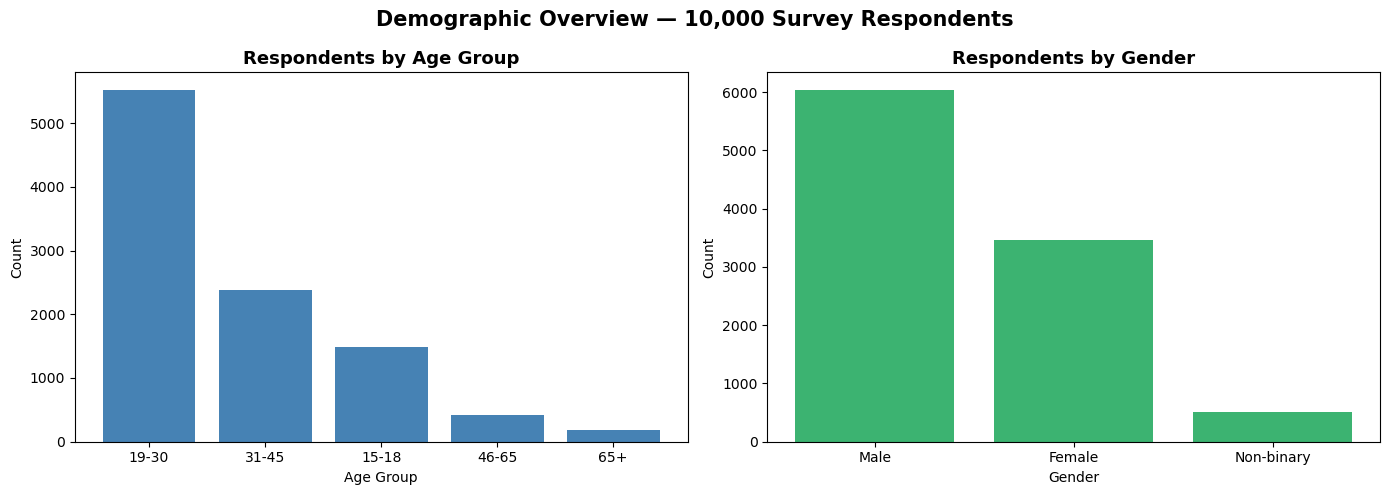

Age
19-30    5520
31-45    2376
15-18    1488
46-65     426
65+       190
Name: count, dtype: int64

Gender
Male          6038
Female        3455
Non-binary     507
Name: count, dtype: int64


In [46]:
age_counts    = df_master["Age"].value_counts()
gender_counts = df_master["Gender"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(age_counts.index, age_counts.values, color="steelblue")
axes[0].set_title("Respondents by Age Group", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Count")

axes[1].bar(gender_counts.index, gender_counts.values, color="mediumseagreen")
axes[1].set_title("Respondents by Gender", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Count")

plt.suptitle("Demographic Overview — 10,000 Survey Respondents", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(age_counts)
print()
print(gender_counts)


### 💡 Insight 1
> **Males aged 19–30 are CodeX's primary target segment**, representing 55.2% of all respondents  
> and the highest energy drink consumption group.  
> The 15–18 group is 3rd largest but has low spending power.  
> CodeX should focus marketing spend on the **19–30 male segment** through digital channels —  
> they have both purchasing power and the highest consumption frequency.


---
## Analysis 2 — Brand Awareness by City

### Business Question: Where does CodeX have the strongest presence?

> *Raw counts can mislead — we calculate true awareness rate (Yes / Total per city × 100)*


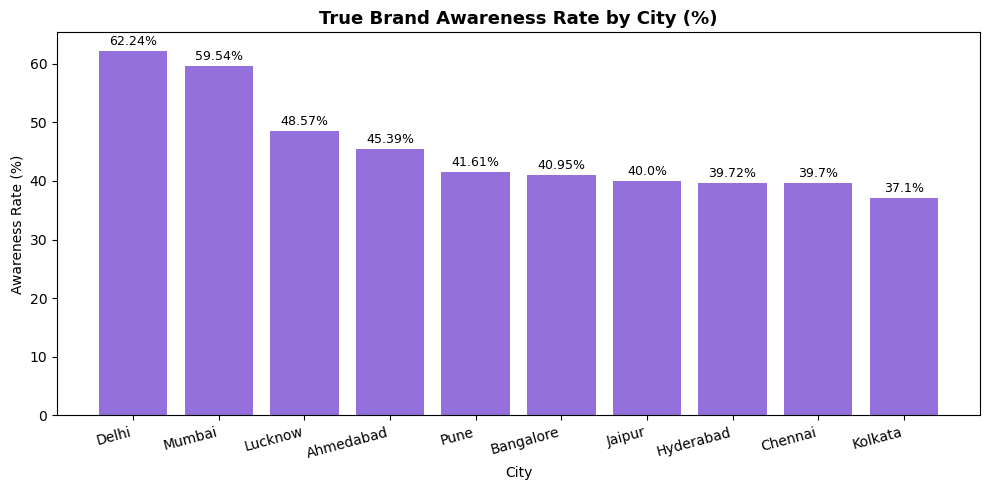

City
Delhi        62.24
Mumbai       59.54
Lucknow      48.57
Ahmedabad    45.39
Pune         41.61
Bangalore    40.95
Jaipur       40.00
Hyderabad    39.72
Chennai      39.70
Kolkata      37.10
Name: count, dtype: float64


In [50]:
df_brand_awareness = df_master[df_master["Heard_before"] == "Yes"]

A = df_brand_awareness["City"].value_counts()
B = df_master["City"].value_counts()
true_awareness_rate = (A / B * 100).sort_values(ascending=False).round(2)

plt.figure(figsize=(10, 5))
bars = plt.bar(true_awareness_rate.index, true_awareness_rate.values, color="mediumpurple")
plt.title("True Brand Awareness Rate by City (%)", fontsize=13, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Awareness Rate (%)")
plt.xticks(rotation=15, ha="right")
for bar, val in zip(bars, true_awareness_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(true_awareness_rate)


### 💡 Insight 2
> **Delhi leads with 62.2% true brand awareness, followed by Mumbai at 59.5%.**  
> Despite having the most respondents, Bangalore's awareness is only 40.9%.  
> CodeX should **double down on Delhi and Mumbai** where awareness is already strong,  
> and invest in **Kolkata (37.1%) and Chennai (39.7%)** to build presence in untapped markets.


---
## Analysis 3 — Competition Analysis

### Business Question: Why are consumers choosing competitor brands over CodeX?


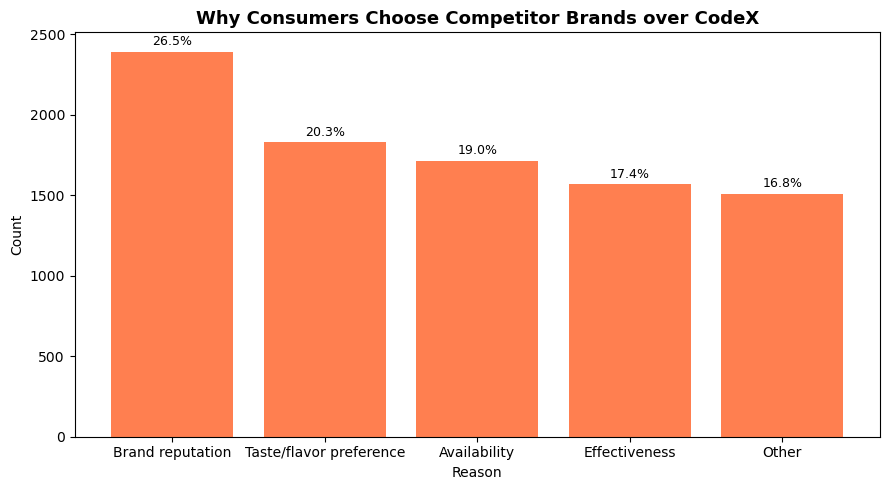

Total non-CodeX users: 9020 (90.2% of all respondents)
Reasons_for_choosing_brands
Brand reputation           2393
Taste/flavor preference    1829
Availability               1715
Effectiveness              1572
Other                      1511
Name: count, dtype: int64


In [55]:
df_competitors = df_master[df_master["Current_brands"] != "CodeX"]
df_reason = df_competitors["Reasons_for_choosing_brands"].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar(df_reason.index, df_reason.values, color="coral")
plt.title("Why Consumers Choose Competitor Brands over CodeX", fontsize=13, fontweight="bold")
plt.xlabel("Reason")
plt.ylabel("Count")
for bar, val in zip(bars, df_reason.values):
    pct = round(val/9020*100, 1)
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{pct}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Total non-CodeX users: {df_competitors.shape[0]} ({round(9020/10000*100,1)}% of all respondents)")
print(df_reason)


### 💡 Insight 3
> **90.2% of respondents prefer competitor brands.**  
> Top barriers: brand reputation (26.5%), taste preference (20.3%), and availability (19%).  
> CodeX should launch **influencer-led reputation campaigns**, conduct **taste testing**  
> with the 19–30 segment, and partner with **Blinkit, Zepto and Amazon**  
> to improve last-mile availability.


---
## Analysis 4 — Product Improvements Desired

### Business Question: What do customers want changed in energy drinks?


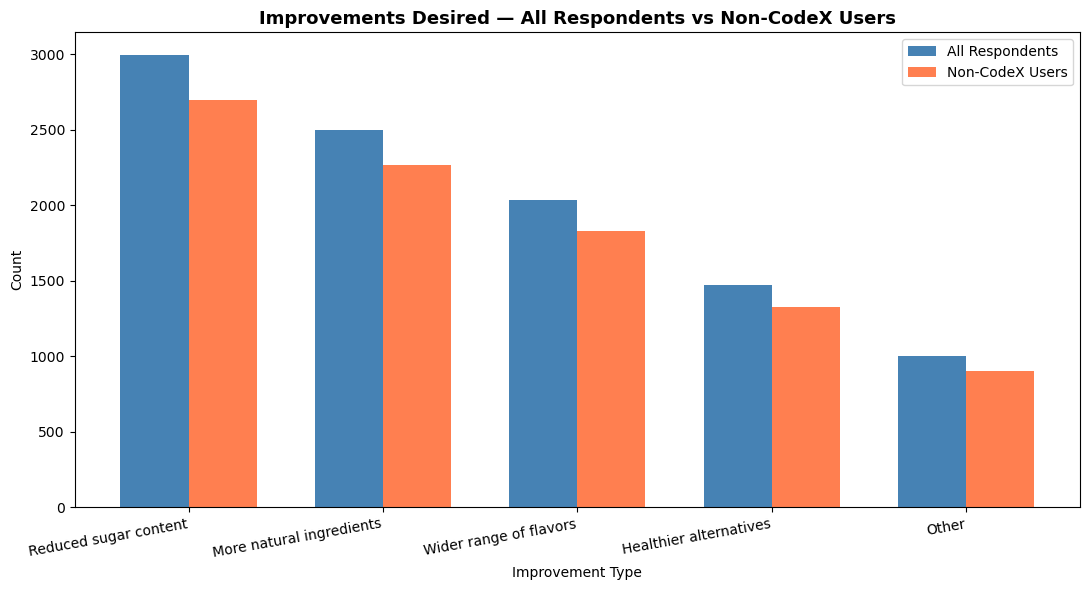

Improvements_desired
Reduced sugar content       2995
More natural ingredients    2498
Wider range of flavors      2037
Healthier alternatives      1472
Other                        998
Name: count, dtype: int64


In [59]:
all_improvements         = df_master["Improvements_desired"].value_counts()
competitor_improvements  = df_competitors["Improvements_desired"].value_counts()

x     = np.arange(len(all_improvements.index))
width = 0.35

plt.figure(figsize=(11, 6))
bars1 = plt.bar(x - width/2, all_improvements.values, width, label="All Respondents", color="steelblue")
bars2 = plt.bar(x + width/2, competitor_improvements.values, width, label="Non-CodeX Users", color="coral")
plt.xticks(x, all_improvements.index, rotation=10, ha="right")
plt.title("Improvements Desired — All Respondents vs Non-CodeX Users", fontsize=13, fontweight="bold")
plt.xlabel("Improvement Type")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print(all_improvements)


### 💡 Insight 4
> The top improvement demanded across **all 10,000 respondents** is reduced sugar (29.9%),  
> followed by natural ingredients (25%) and wider flavors (20.4%).  
> **This pattern holds even among non-CodeX users** — confirming an industry-wide shift  
> toward healthier drinks. CodeX has a **first-mover opportunity** to reformulate  
> with low sugar, natural caffeine (Guarana), and new flavors before competitors do.


---
## Analysis 5 — Marketing Channel Effectiveness

### Business Question: Where should CodeX spend its advertising budget?


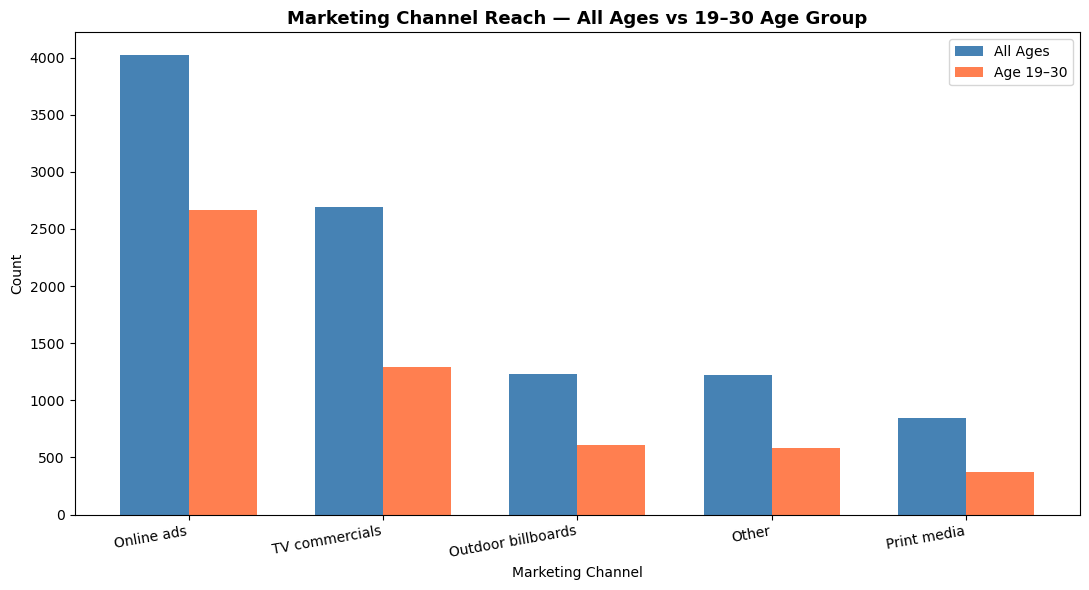

All ages: {'Online ads': 4020, 'TV commercials': 2688, 'Outdoor billboards': 1226, 'Other': 1225, 'Print media': 841}
19-30 age: {'Online ads': 2666, 'TV commercials': 1290, 'Other': 608, 'Outdoor billboards': 585, 'Print media': 371}


In [63]:
all_channels  = df_master["Marketing_channels"].value_counts()
youth_channels = df_master[df_master["Age"] == "19-30"]["Marketing_channels"].value_counts()

x     = np.arange(len(all_channels.index))
width = 0.35

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, all_channels.values,  width, label="All Ages",      color="steelblue")
plt.bar(x + width/2, youth_channels.values, width, label="Age 19–30",     color="coral")
plt.xticks(x, all_channels.index, rotation=10, ha="right")
plt.title("Marketing Channel Reach — All Ages vs 19–30 Age Group", fontsize=13, fontweight="bold")
plt.xlabel("Marketing Channel")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("All ages:", all_channels.to_dict())
print("19-30 age:", youth_channels.to_dict())


### 💡 Insight 5
> **Online ads dominate across all age groups (40.2%)**, and this is even stronger  
> among the 19–30 segment (48.3% of their channel exposure).  
> CodeX should allocate the majority of ad budget to **YouTube and Instagram**,  
> followed by TV commercials. **Print media (8.4%) should be deprioritized entirely.**


---
## Analysis 6 & 7 — Consumer Preferences: Ingredients & Packaging


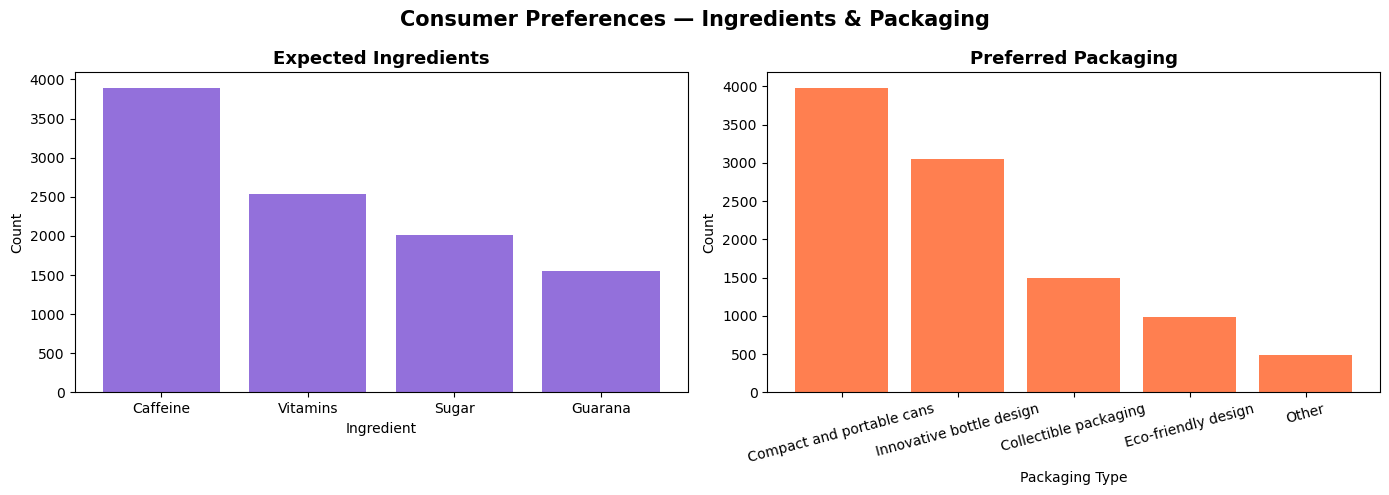

Ingredients_expected
Caffeine    3896
Vitamins    2534
Sugar       2017
Guarana     1553
Name: count, dtype: int64

Packaging_preference
Compact and portable cans    3984
Innovative bottle design     3047
Collectible packaging        1501
Eco-friendly design           983
Other                         485
Name: count, dtype: int64


In [67]:
ingredients  = df_master["Ingredients_expected"].value_counts()
packaging    = df_master["Packaging_preference"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(ingredients.index, ingredients.values, color="mediumpurple")
axes[0].set_title("Expected Ingredients", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Ingredient")
axes[0].set_ylabel("Count")

axes[1].bar(packaging.index, packaging.values, color="coral")
axes[1].set_title("Preferred Packaging", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Packaging Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Consumer Preferences — Ingredients & Packaging", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(ingredients)
print()
print(packaging)


### 💡 Insight 6 & 7
> **Caffeine (38.9%) and Vitamins (25.3%)** are the top expected ingredients —  
> CodeX must ensure both are prominently featured on packaging.  
> For design, **compact portable cans (39.8%)** and **innovative bottle design (30.5%)**  
> are strongly preferred. Eco-friendly packaging (9.8%) is a future differentiator  
> as sustainability awareness grows among youth.


---
## Analysis 8 — Current Market Leaders

### Business Question: Who is CodeX really competing against?


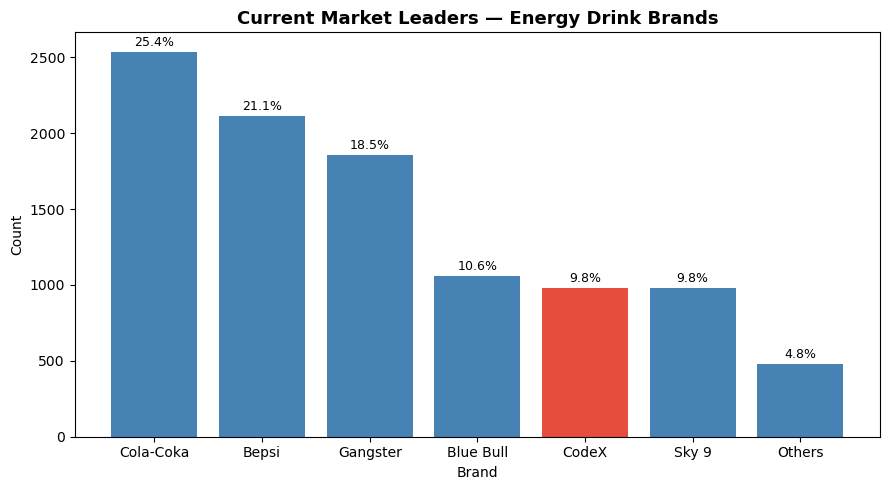

Current_brands
Cola-Coka    2538
Bepsi        2112
Gangster     1854
Blue Bull    1058
CodeX         980
Sky 9         979
Others        479
Name: count, dtype: int64


In [71]:
market = df_master["Current_brands"].value_counts()

colors = ["#e74c3c" if b == "CodeX" else "steelblue" for b in market.index]

plt.figure(figsize=(9, 5))
bars = plt.bar(market.index, market.values, color=colors)
plt.title("Current Market Leaders — Energy Drink Brands", fontsize=13, fontweight="bold")
plt.xlabel("Brand")
plt.ylabel("Count")
for bar, val in zip(bars, market.values):
    pct = round(val/10000*100, 1)
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{pct}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(market)


### 💡 Insight 8
> **Cola-Coka (25.4%) and Bepsi (21.1%) dominate the market**  
> while CodeX sits at just **9.8%** — on par with Sky 9.  
> Both leaders win on brand reputation and availability —  
> the exact two factors CodeX scores lowest on.  
> *Note: CodeX bar is highlighted in red for quick visual reference.*


---
##  Analysis 9 — Brand Perception

### Business Question: What do people think about CodeX's brand?


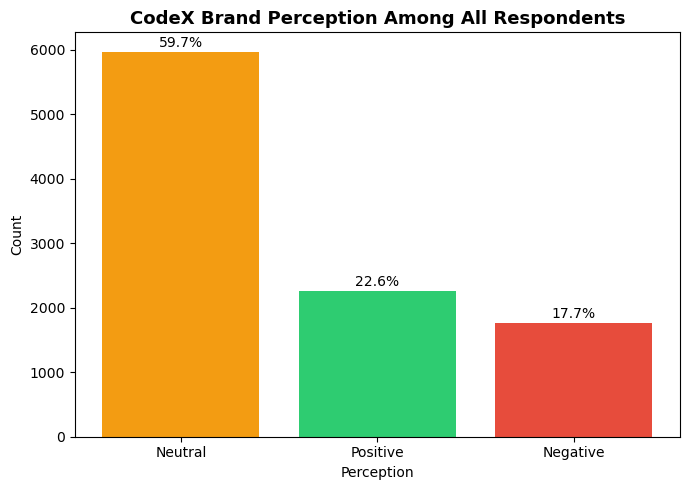

Brand_perception
Neutral     5974
Positive    2257
Negative    1769
Name: count, dtype: int64


In [75]:
perception = df_master["Brand_perception"].value_counts()

colors = {"Positive": "#2ecc71", "Neutral": "#f39c12", "Negative": "#e74c3c"}
bar_colors = [colors[p] for p in perception.index]

plt.figure(figsize=(7, 5))
bars = plt.bar(perception.index, perception.values, color=bar_colors)
plt.title("CodeX Brand Perception Among All Respondents", fontsize=13, fontweight="bold")
plt.xlabel("Perception")
plt.ylabel("Count")
for bar, val in zip(bars, perception.values):
    pct = round(val/10000*100, 1)
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"{pct}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

print(perception)


### 💡 Insight 9
> Only **22.6% hold a positive perception** of CodeX's brand,  
> while **59.7% remain neutral** — indicating low brand familiarity, not active dislike.  
> This neutral majority is CodeX's **biggest conversion opportunity**.  
> With targeted brand-building campaigns, undecided consumers can be converted.  
> Only 17.7% hold a negative perception — no serious image damage to repair.


---
## Analysis 10 & 11 — Purchase Behaviour: Location, Situations & Price


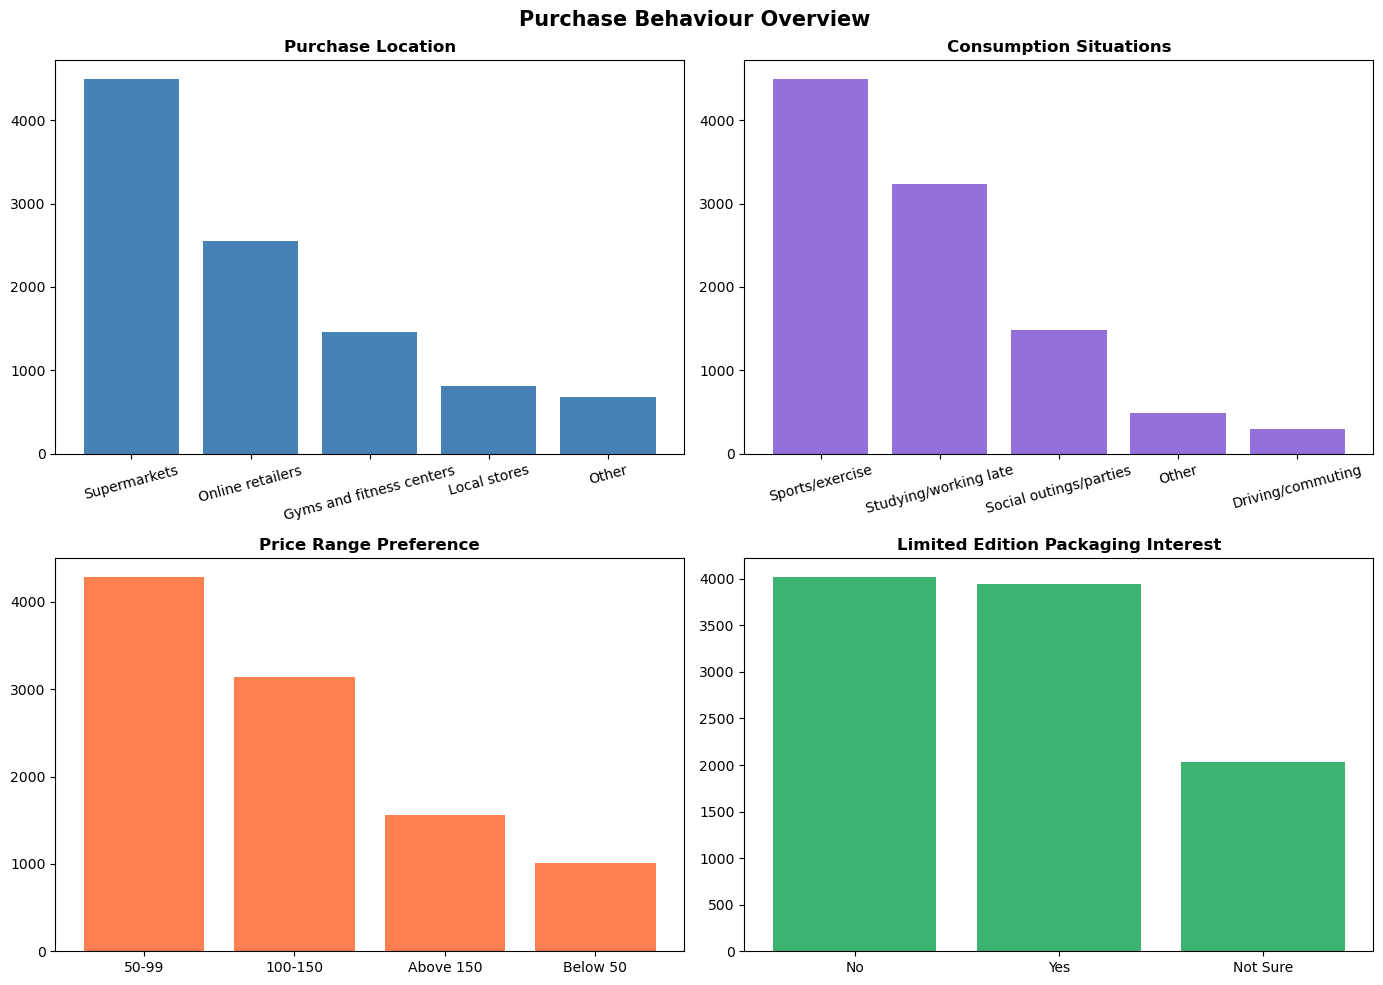

In [79]:
purchase_loc  = df_master["Purchase_location"].value_counts()
situations    = df_master["Typical_consumption_situations"].value_counts()
price_range   = df_master["Price_range"].value_counts()
limited_ed    = df_master["Limited_edition_packaging"].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].bar(purchase_loc.index, purchase_loc.values, color="steelblue")
axes[0,0].set_title("Purchase Location", fontweight="bold")
axes[0,0].tick_params(axis="x", rotation=15)

axes[0,1].bar(situations.index, situations.values, color="mediumpurple")
axes[0,1].set_title("Consumption Situations", fontweight="bold")
axes[0,1].tick_params(axis="x", rotation=15)

axes[1,0].bar(price_range.index, price_range.values, color="coral")
axes[1,0].set_title("Price Range Preference", fontweight="bold")

axes[1,1].bar(limited_ed.index, limited_ed.values, color="mediumseagreen")
axes[1,1].set_title("Limited Edition Packaging Interest", fontweight="bold")

plt.suptitle("Purchase Behaviour Overview", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


### 💡 Insights 10 & 11
> - **Purchase:** 44.9% buy from supermarkets, 25.5% online — CodeX must urgently  
>   secure supermarket shelf space and list on Blinkit, Zepto and Amazon.  
> - **Situations:** 44.9% consume during sports/exercise, 32.3% while studying/working late —  
>   CodeX should sponsor marathons and target college campuses with vending machines.  
> - **Price:** 42.9% prefer ₹50–99, yet CodeX is priced at ₹150 — outside the comfort  
>   zone of 74% of respondents. A smaller SKU under ₹99 could expand the addressable market.  
> - **Limited Edition:** Near 50-50 split — reserve special packaging for high-impact events  
>   like IPL, Cricket World Cup, and Diwali only.


---
## Supporting Analysis — Health Trends & Barriers to Trial


In [84]:
print("=== Barriers to Trying CodeX ===")
print(df_master["Reasons_preventing_trying"].value_counts())
print()
print("=== Health Concerns ===")
print(df_master["Health_concerns"].value_counts())
print()
print("=== Interest in Natural/Organic ===")
print(df_master["Interest_in_natural_or_organic"].value_counts())


=== Barriers to Trying CodeX ===
Reasons_preventing_trying
Not available locally              2431
Health concerns                    2258
Not interested in energy drinks    2193
Unfamiliar with the brand          1850
Other                              1268
Name: count, dtype: int64

=== Health Concerns ===
Health_concerns
Yes    6045
No     3955
Name: count, dtype: int64

=== Interest in Natural/Organic ===
Interest_in_natural_or_organic
Yes         4983
No          3062
Not Sure    1955
Name: count, dtype: int64


### 💡 Supporting Insights
> - **Top barrier to trial:** Unavailability (24.3%), health concerns (22.6%), brand unfamiliarity (18.5%)  
>   — CodeX's growth is blocked by distribution and awareness gaps, **not product rejection.**  
> - **60.5% of respondents** are concerned about health impacts — making a natural,  
>   low-sugar formulation a market necessity, not just a preference.  
> - **49.8% would be interested** in a natural/organic energy drink —  
>   a clear signal for a 'Clean Energy' CodeX variant.


---
## 🚀 Final Recommendations for CodeX

Based on analysis of 10,000 survey responses across 10 Indian cities:

---

### Recommendation 1 — Immediate Product Improvement
> Reduce sugar content and add natural ingredients — demanded by 29.9% and 25% of respondents.  
> Launch a **'Natural Energy' variant** with low sugar, Guarana-based caffeine,  
> and 2–3 new flavors (mango, mint) to directly address the top three improvement demands.

---

### Recommendation 2 — Ideal Pricing
> CodeX's current ₹150 price point is above the comfort zone of **74% of respondents**.  
> Introduce a **smaller SKU priced at ₹89–99** targeting students and the 19–30 segment.  
> Keep the existing 250ml can at ₹120 (reduced from ₹150) to improve trial rate.

---

### Recommendation 3 — Marketing Campaign
> Launch a **'Fuel Your Hustle' digital campaign** targeting males aged 19–30  
> on Instagram and YouTube. Sponsor marathons, college fests, and gym events  
> for physical brand touchpoints. Run a 20–25% launch discount bringing price to ₹99–120.  
> Distribute **student combo packs** at colleges in Delhi and Mumbai — highest awareness cities.

---

### Recommendation 4 — Brand Ambassador
> **Primary:** Shubman Gill — aged 25, massive Instagram reach, associated with  
> performance and youth energy, one of India's most marketable cricketers.  
> **Digital Creators:** Partner with Saket Gokhale and Daniel J Samuel (That Mallu Guy)  
> who lead Hyrox and functional fitness communities — reaching the sports/exercise  
> consumption segment (44.9% of users) through authentic, trusted content.

---

### Recommendation 5 — Distribution & Availability
> List CodeX on **Blinkit, Zepto, Amazon, and Flipkart** immediately.  
> Secure shelf space in supermarket chains (44.9% of purchase location).  
> Place vending machines at **gyms, college campuses, and corporate offices**  
> to capture the sports (44.9%) and study/work (32.3%) consumption occasions.

---
